# Sentiment Analysis of Amazon Product Reviews
## Comparing Traditional and Modern Text Mining Approaches

**MSc in Economics with Data Science — Text Mining Project**

This project analyzes Amazon food reviews to classify them as positive or negative.
We compare different text representation strategies (TF, TF-IDF, n-grams, word embeddings)
and evaluate their impact on classification performance.

**Dataset**: Amazon Fine Food Reviews from Kaggle (568,454 reviews)
- Download from: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
- Place the `Reviews.csv` file in the same folder as this notebook

The dataset contains columns: `Text` (review text) and `Score` (1-5 stars).
We convert ratings into binary sentiment: positive (4-5 stars) vs negative (1-2 stars).
We sample a balanced subset of 5,000 reviews per class (10,000 total) for tractable computation.

## 1. Initial Setup

In [1]:
# Run once to install dependencies (then comment out)
!pip install spacy nltk pandas matplotlib seaborn scikit-learn wordcloud sentence-transformers torch
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------------------ --------------------- 5.8/12.8 MB 29.3 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 31.5 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 28.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from nltk.corpus import wordnet
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

nltk.download('omw-1.4', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

nlp = spacy.load('en_core_web_sm')

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. Load and Prepare the Dataset

In [3]:
# Load the Amazon Fine Food Reviews dataset
# Download from: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
df_raw = pd.read_csv('Reviews.csv')

print(f"Full dataset: {df_raw.shape[0]:,} reviews")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nScore distribution:")
print(df_raw['Score'].value_counts().sort_index())
df_raw.head(3)

Full dataset: 568,454 reviews
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Score distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


In [4]:
# Keep only Text and Score, drop missing values, remove neutrals (score=3)
df_all = df_raw[['Text', 'Score']].dropna()
df_all.columns = ['text', 'rating']
df_all = df_all[df_all['rating'] != 3].copy()
df_all['sentiment'] = df_all['rating'].apply(lambda x: 'positive' if x >= 4 else 'negative')

print(f"After removing neutrals and NaNs: {len(df_all):,} reviews")
print(f"\nFull sentiment distribution:")
print(df_all['sentiment'].value_counts())
print(f"Imbalance ratio: {df_all['sentiment'].value_counts()['positive'] / df_all['sentiment'].value_counts()['negative']:.1f}:1")

After removing neutrals and NaNs: 525,814 reviews

Full sentiment distribution:
sentiment
positive    443777
negative     82037
Name: count, dtype: int64
Imbalance ratio: 5.4:1


In [5]:
# Create a BALANCED sample: 5,000 per class = 10,000 total
SAMPLES_PER_CLASS = 5000

df_neg = df_all[df_all['sentiment'] == 'negative'].sample(n=SAMPLES_PER_CLASS, random_state=42)
df_pos = df_all[df_all['sentiment'] == 'positive'].sample(n=SAMPLES_PER_CLASS, random_state=42)
df = pd.concat([df_neg, df_pos]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset: {len(df):,} reviews")
print(df['sentiment'].value_counts())
print(f"\nBaseline accuracy (random): 50.0%")

Balanced dataset: 10,000 reviews
sentiment
positive    5000
negative    5000
Name: count, dtype: int64

Baseline accuracy (random): 50.0%


## 3. Exploratory Analysis

### 3.1 Review length distribution

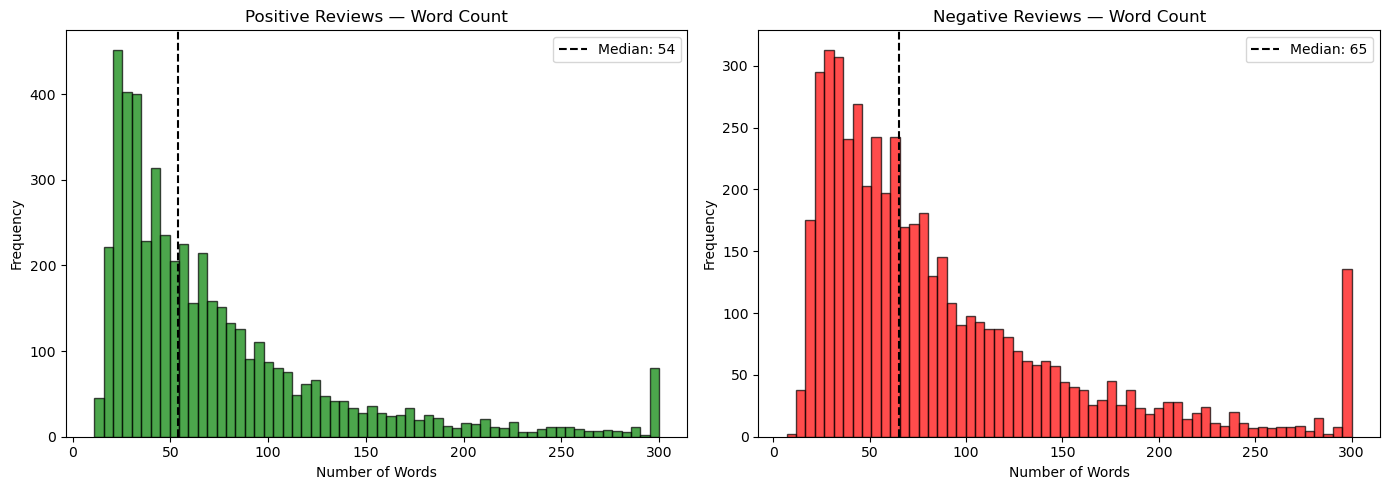

In [6]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, sentiment in enumerate(['positive', 'negative']):
    subset = df[df['sentiment'] == sentiment]
    axes[i].hist(subset['word_count'].clip(upper=300), bins=60,
                 color='green' if sentiment == 'positive' else 'red', alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{sentiment.capitalize()} Reviews — Word Count')
    axes[i].set_xlabel('Number of Words')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(subset['word_count'].median(), color='black', linestyle='--',
                    label=f'Median: {subset["word_count"].median():.0f}')
    axes[i].legend()
plt.tight_layout()
plt.savefig('review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Word clouds

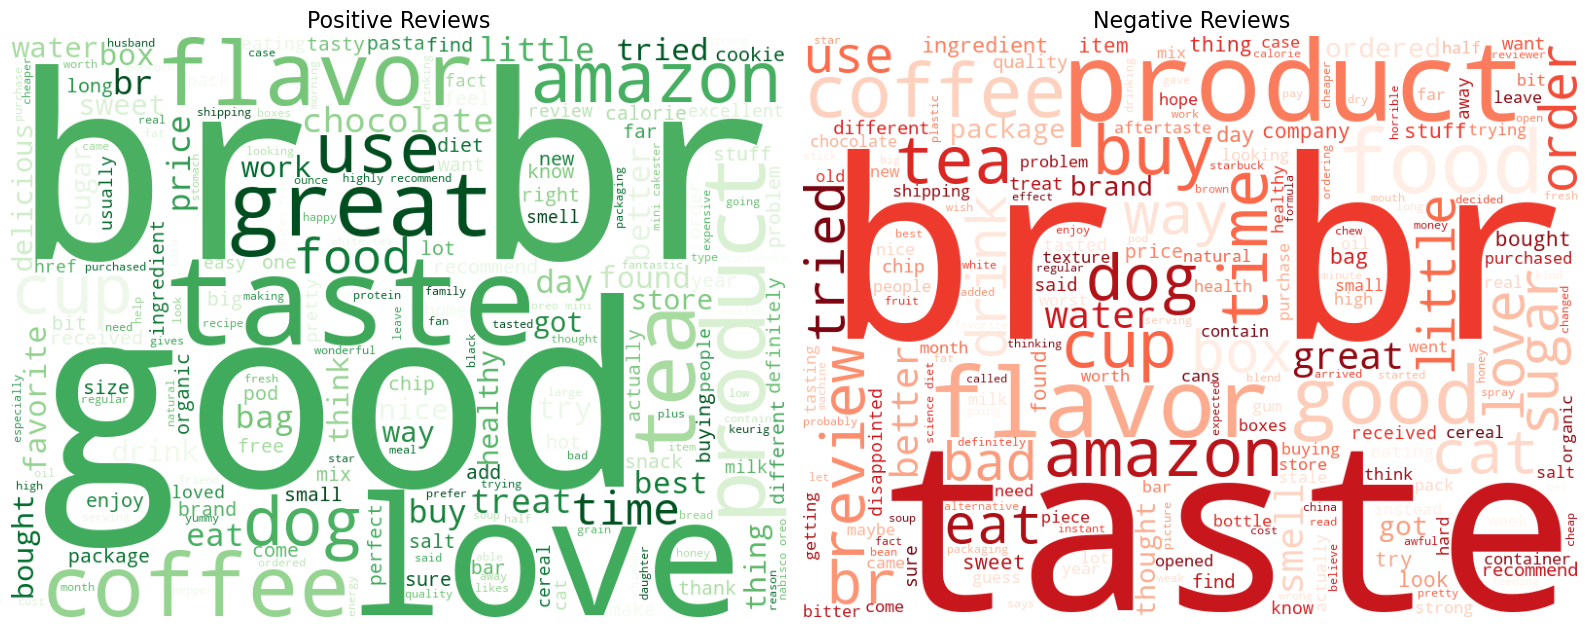

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for i, sentiment in enumerate(['positive', 'negative']):
    subset = df[df['sentiment'] == sentiment]
    sample_text = ' '.join(subset['text'].astype(str).sample(min(1500, len(subset)), random_state=42).tolist())
    doc = nlp(sample_text[:200000])
    tokens = [w.lower_ for w in doc if (not w.is_space and not w.is_punct and not w.is_stop and len(w.text) > 2)]
    text_clean = ' '.join(tokens)

    cmap = 'Greens' if sentiment == 'positive' else 'Reds'
    wc = WordCloud(width=800, height=600, background_color='white', colormap=cmap, min_font_size=10).generate(text_clean)
    axes[i].imshow(wc)
    axes[i].set_title(f'{sentiment.capitalize()} Reviews', fontsize=16)
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('wordclouds_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 POS-tag analysis

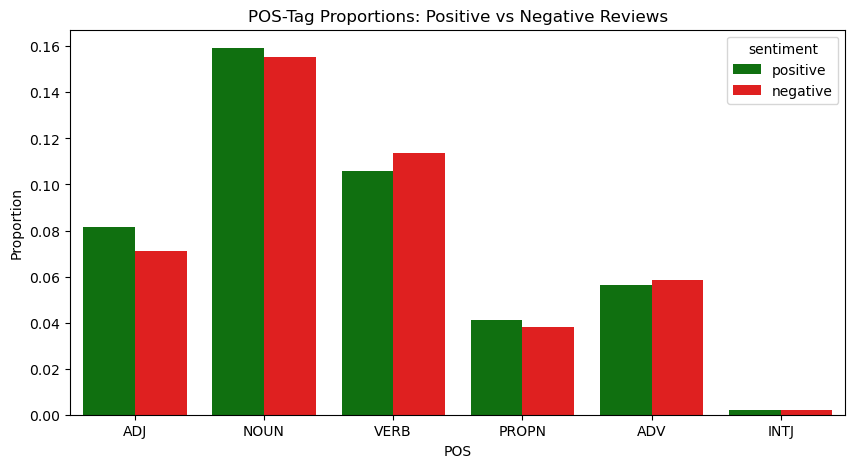

In [8]:
pos_data = []
for sentiment in ['positive', 'negative']:
    subset = df[df['sentiment'] == sentiment]
    sample_text = ' '.join(subset['text'].astype(str).sample(500, random_state=42).tolist())
    doc = nlp(sample_text[:150000])
    pos_counts = {}
    total = 0
    for token in doc:
        pos_counts[token.pos_] = pos_counts.get(token.pos_, 0) + 1
        total += 1
    for pos, count in pos_counts.items():
        pos_data.append({'sentiment': sentiment, 'POS': pos, 'proportion': count / total})

pos_df = pd.DataFrame(pos_data)
interesting_pos = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN', 'INTJ']
pos_df_filtered = pos_df[pos_df['POS'].isin(interesting_pos)]

plt.figure(figsize=(10, 5))
sns.barplot(data=pos_df_filtered, x='POS', y='proportion', hue='sentiment',
            palette={'positive': 'green', 'negative': 'red'})
plt.title('POS-Tag Proportions: Positive vs Negative Reviews')
plt.ylabel('Proportion')
plt.savefig('pos_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Named Entity Recognition

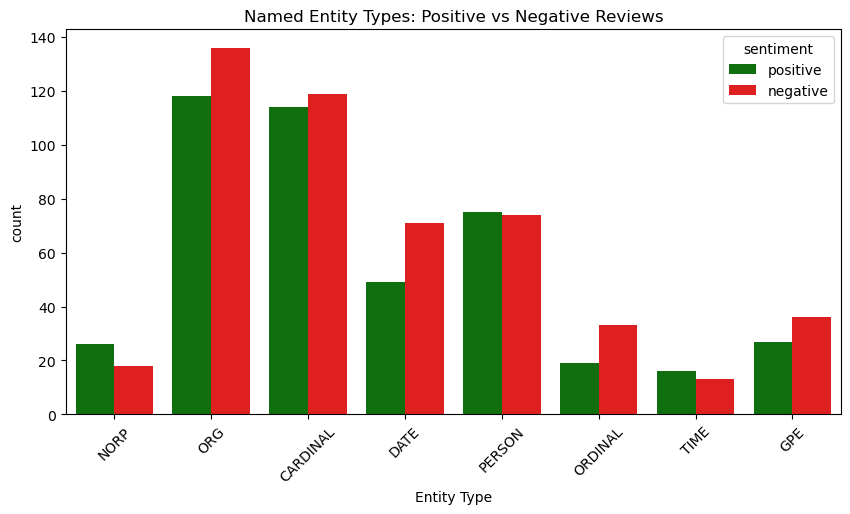

In [9]:
ner_data = []
for sentiment in ['positive', 'negative']:
    subset = df[df['sentiment'] == sentiment]
    sample_text = ' '.join(subset['text'].astype(str).sample(300, random_state=42).tolist())
    doc = nlp(sample_text[:80000])
    ent_counts = {}
    for ent in doc.ents:
        ent_counts[ent.label_] = ent_counts.get(ent.label_, 0) + 1
    for label, count in ent_counts.items():
        ner_data.append({'sentiment': sentiment, 'Entity Type': label, 'count': count})

ner_df = pd.DataFrame(ner_data)
top_types = ner_df.groupby('Entity Type')['count'].sum().nlargest(8).index
ner_df_filtered = ner_df[ner_df['Entity Type'].isin(top_types)]

plt.figure(figsize=(10, 5))
sns.barplot(data=ner_df_filtered, x='Entity Type', y='count', hue='sentiment',
            palette={'positive': 'green', 'negative': 'red'})
plt.title('Named Entity Types: Positive vs Negative Reviews')
plt.xticks(rotation=45)
plt.savefig('ner_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 N-gram analysis

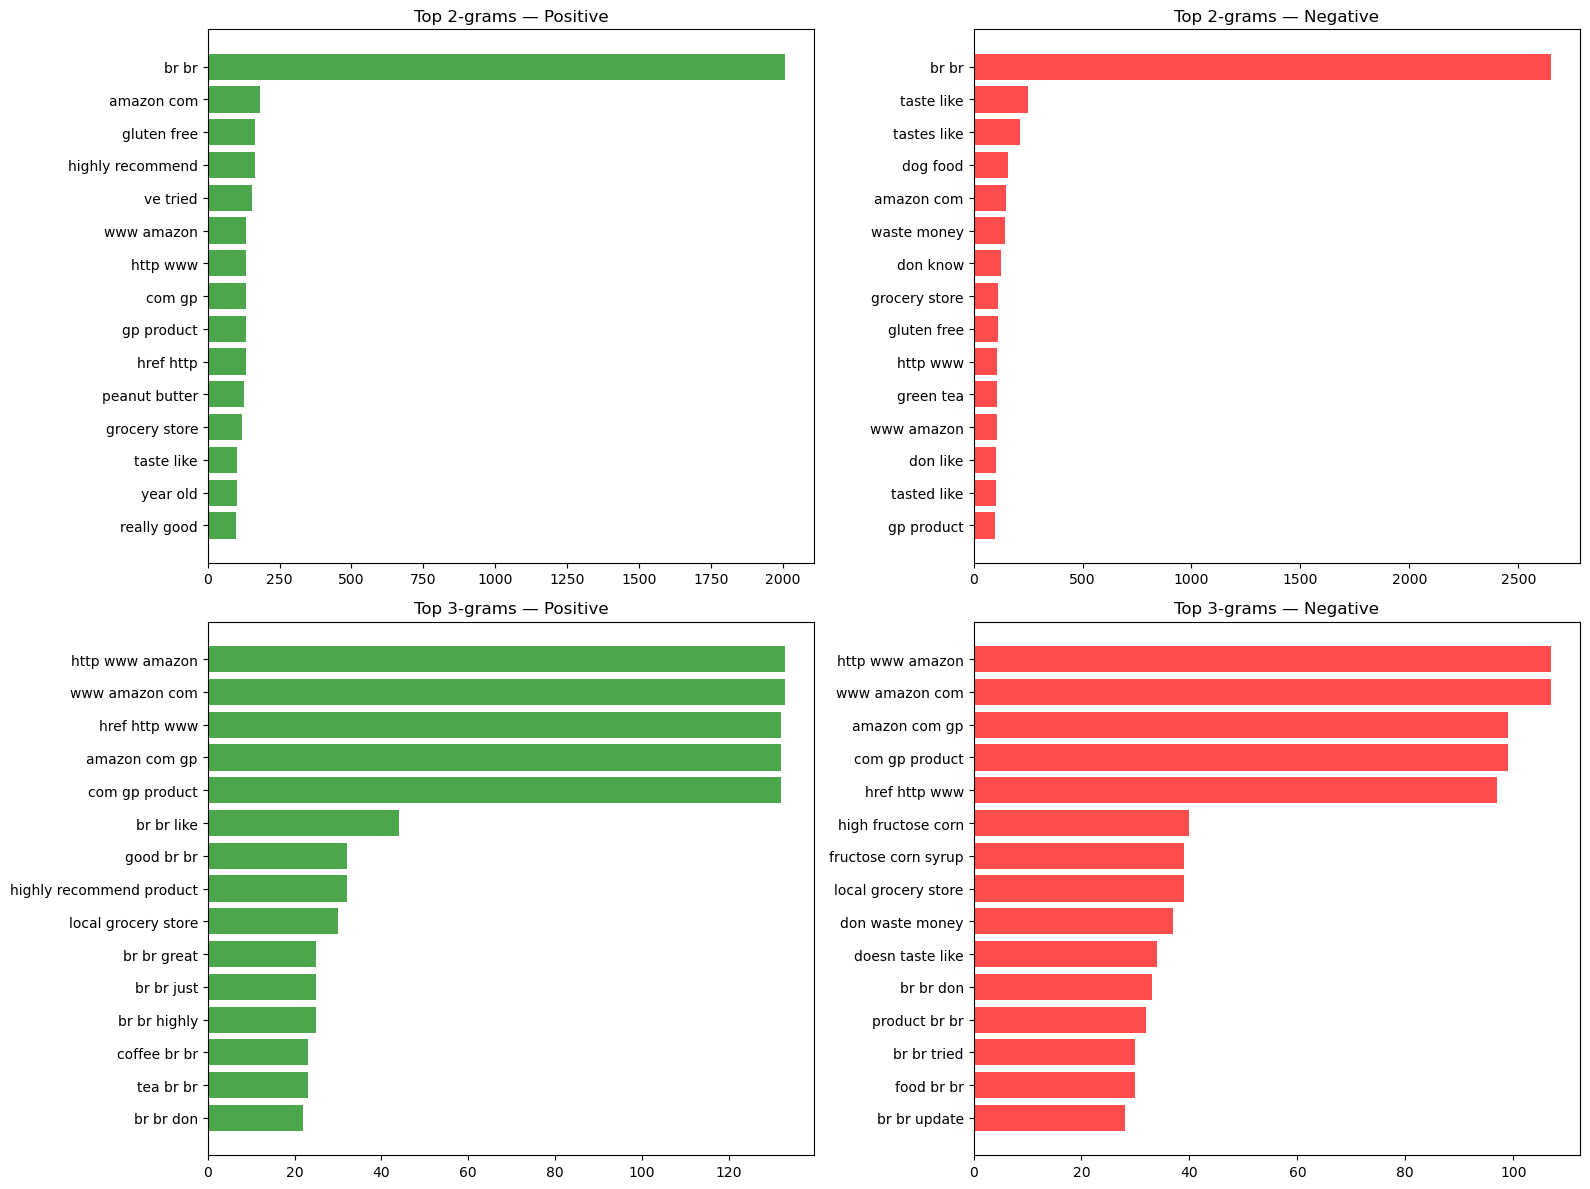

In [10]:
def get_top_ngrams(texts, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10000)
    X = vec.fit_transform(texts)
    freqs = X.sum(axis=0).A1
    terms = vec.get_feature_names_out()
    top_idx = freqs.argsort()[-top_k:][::-1]
    return [(terms[i], freqs[i]) for i in top_idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for col, (sentiment, color) in enumerate(zip(['positive', 'negative'], ['green', 'red'])):
    subset = df[df['sentiment'] == sentiment]['text'].astype(str).tolist()
    for row, n in enumerate([2, 3]):
        ngrams = get_top_ngrams(subset, n=n, top_k=15)
        terms, counts = zip(*ngrams)
        axes[row][col].barh(range(len(terms)), counts, color=color, alpha=0.7)
        axes[row][col].set_yticks(range(len(terms)))
        axes[row][col].set_yticklabels(terms)
        axes[row][col].invert_yaxis()
        axes[row][col].set_title(f'Top {n}-grams — {sentiment.capitalize()}')
plt.tight_layout()
plt.savefig('ngram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 WordNet: synonyms and antonyms

In [11]:
sentiment_words = ['good', 'bad', 'excellent', 'terrible', 'love', 'hate']
for word in sentiment_words:
    synsets = wordnet.synsets(word)
    synonyms, antonyms = set(), set()
    for synset in synsets:
        for lemma in synset.lemmas():
            synonyms.add(lemma.name())
            if lemma.antonyms():
                antonyms.add(lemma.antonyms()[0].name())
    print(f"'{word}' -> Synonyms: {list(synonyms)[:5]} | Antonyms: {list(antonyms)[:3]}")

'good' -> Synonyms: ['proficient', 'expert', 'secure', 'effective', 'practiced'] | Antonyms: ['ill', 'evilness', 'badness']
'bad' -> Synonyms: ['uncollectible', 'tough', 'badly', 'spoilt', 'speculative'] | Antonyms: ['good', 'unregretful', 'goodness']
'excellent' -> Synonyms: ['fantabulous', 'first-class', 'excellent', 'splendid'] | Antonyms: []
'terrible' -> Synonyms: ['unspeakable', 'direful', 'horrific', 'wicked', 'fearsome'] | Antonyms: []
'love' -> Synonyms: ['have_it_off', 'jazz', 'have_it_away', 'make_out', 'have_intercourse'] | Antonyms: ['hate']
'hate' -> Synonyms: ['hatred', 'detest', 'hate'] | Antonyms: ['love']


## 4. Text Preprocessing

In [12]:
stemmer = PorterStemmer()

def preprocess_text(text, use_lemma=False, use_stem=False):
    """Lowercase, remove punctuation/stopwords, optionally lemmatize/stem."""
    doc = nlp(str(text).lower())
    tokens = [t for t in doc if not t.is_punct and not t.is_space and not t.is_stop]
    if use_lemma:
        return ' '.join([t.lemma_ for t in tokens])
    elif use_stem:
        return ' '.join([stemmer.stem(t.text) for t in tokens])
    return ' '.join([t.text for t in tokens])


# Preprocess all 10,000 reviews
print("Preprocessing 10,000 reviews with SpaCy lemmatisation...")
print("(This will take approximately 10-15 minutes)")

df['text_clean'] = df['text'].apply(lambda x: preprocess_text(x, use_lemma=True))

print("Done!")
print(f"\nExample:")
print(f"  Original:     {df['text'].iloc[0][:120]}...")
print(f"  Preprocessed: {df['text_clean'].iloc[0][:120]}...")

Preprocessing 10,000 reviews with SpaCy lemmatisation...
(This will take approximately 10-15 minutes)
Done!

Example:
  Original:     Popchips are no ordinary chips. What's in them is as good as what's not in them.<br />No preservatives. No artificial fl...
  Preprocessed: popchip ordinary chip good them.<br />no preservative artificial flavor saturate fat gluten ingredients.<br />popchips t...


## 5. Feature Representation

In [13]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['text_clean'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment']
)
print(f"Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")
print(f"Train: {y_train.value_counts().to_dict()} | Test: {y_test.value_counts().to_dict()}")

Train: 8000 | Test: 2000
Train: {'negative': 4000, 'positive': 4000} | Test: {'negative': 1000, 'positive': 1000}


In [14]:
tf_uni = CountVectorizer(ngram_range=(1,1))
X_tr_tf1 = tf_uni.fit_transform(X_train_raw)
X_te_tf1 = tf_uni.transform(X_test_raw)
print(f"TF Unigrams: {X_tr_tf1.shape[1]} features")

tf_bi = CountVectorizer(ngram_range=(1,2), max_features=80000)
X_tr_tf2 = tf_bi.fit_transform(X_train_raw)
X_te_tf2 = tf_bi.transform(X_test_raw)
print(f"TF Uni+Bigrams: {X_tr_tf2.shape[1]} features")

tfidf_uni = TfidfVectorizer(ngram_range=(1,1))
X_tr_tfidf1 = tfidf_uni.fit_transform(X_train_raw)
X_te_tfidf1 = tfidf_uni.transform(X_test_raw)
print(f"TF-IDF Unigrams: {X_tr_tfidf1.shape[1]} features")

tfidf_bi = TfidfVectorizer(ngram_range=(1,2), max_features=80000)
X_tr_tfidf2 = tfidf_bi.fit_transform(X_train_raw)
X_te_tfidf2 = tfidf_bi.transform(X_test_raw)
print(f"TF-IDF Uni+Bigrams: {X_tr_tfidf2.shape[1]} features")

tfidf_tri = TfidfVectorizer(ngram_range=(1,3), max_features=80000)
X_tr_tfidf3 = tfidf_tri.fit_transform(X_train_raw)
X_te_tfidf3 = tfidf_tri.transform(X_test_raw)
print(f"TF-IDF Uni+Bi+Trigrams: {X_tr_tfidf3.shape[1]} features")

TF Unigrams: 15276 features
TF Uni+Bigrams: 80000 features
TF-IDF Unigrams: 15276 features
TF-IDF Uni+Bigrams: 80000 features
TF-IDF Uni+Bi+Trigrams: 80000 features


## 6. Classification with Cross-Validation

5-fold stratified CV on training set. We report accuracy and macro F1. A majority-class baseline is included.

In [15]:
representations = {
    'TF Unigrams':            (X_tr_tf1,    X_te_tf1),
    'TF Uni+Bigrams':         (X_tr_tf2,    X_te_tf2),
    'TF-IDF Unigrams':        (X_tr_tfidf1, X_te_tfidf1),
    'TF-IDF Uni+Bigrams':     (X_tr_tfidf2, X_te_tfidf2),
    'TF-IDF Uni+Bi+Trigrams': (X_tr_tfidf3, X_te_tfidf3),
}

classifiers = {
    'Naive Bayes':          MultinomialNB(),
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                  LinearSVC(max_iter=3000, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}

# Baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_tr_tf1, y_train)
baseline_acc = accuracy_score(y_test, dummy.predict(X_te_tf1))
baseline_f1 = f1_score(y_test, dummy.predict(X_te_tf1), average='macro')
print(f"Baseline (majority class): Acc={baseline_acc:.3f} | F1={baseline_f1:.3f}\n")

results = []
print("Running 5-fold CV...\n")
for repr_name, (X_tr, X_te) in representations.items():
    for clf_name, clf in classifiers.items():
        cv_res = cross_validate(clf, X_tr, y_train, cv=cv, scoring=scoring)
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)
        test_acc = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average='macro')
        results.append({
            'Representation': repr_name, 'Classifier': clf_name,
            'CV Acc': f"{cv_res['test_accuracy'].mean():.3f}±{cv_res['test_accuracy'].std():.3f}",
            'CV F1': f"{cv_res['test_f1_macro'].mean():.3f}±{cv_res['test_f1_macro'].std():.3f}",
            'Test Acc': test_acc, 'Test F1': test_f1,
        })
        print(f"  {repr_name:28s} + {clf_name:22s} → CV F1={cv_res['test_f1_macro'].mean():.3f}±{cv_res['test_f1_macro'].std():.3f} | Test F1={test_f1:.3f}")

results_df = pd.DataFrame(results)
print("\nDone!")

Baseline (majority class): Acc=0.500 | F1=0.333

Running 5-fold CV...

  TF Unigrams                  + Naive Bayes            → CV F1=0.829±0.010 | Test F1=0.824
  TF Unigrams                  + Logistic Regression    → CV F1=0.846±0.012 | Test F1=0.848
  TF Unigrams                  + SVM                    → CV F1=0.819±0.013 | Test F1=0.828
  TF Uni+Bigrams               + Naive Bayes            → CV F1=0.840±0.015 | Test F1=0.843
  TF Uni+Bigrams               + Logistic Regression    → CV F1=0.853±0.011 | Test F1=0.864
  TF Uni+Bigrams               + SVM                    → CV F1=0.839±0.015 | Test F1=0.856
  TF-IDF Unigrams              + Naive Bayes            → CV F1=0.841±0.009 | Test F1=0.839
  TF-IDF Unigrams              + Logistic Regression    → CV F1=0.853±0.009 | Test F1=0.856
  TF-IDF Unigrams              + SVM                    → CV F1=0.846±0.010 | Test F1=0.855
  TF-IDF Uni+Bigrams           + Naive Bayes            → CV F1=0.852±0.015 | Test F1=0.863
  TF-IDF 

In [16]:
print(results_df[['Representation','Classifier','CV Acc','CV F1','Test Acc','Test F1']].to_string(index=False))

        Representation          Classifier      CV Acc       CV F1  Test Acc  Test F1
           TF Unigrams         Naive Bayes 0.829±0.010 0.829±0.010    0.8240 0.823975
           TF Unigrams Logistic Regression 0.846±0.012 0.846±0.012    0.8480 0.847985
           TF Unigrams                 SVM 0.819±0.013 0.819±0.013    0.8280 0.827986
        TF Uni+Bigrams         Naive Bayes 0.840±0.015 0.840±0.015    0.8435 0.843489
        TF Uni+Bigrams Logistic Regression 0.853±0.011 0.853±0.011    0.8640 0.863991
        TF Uni+Bigrams                 SVM 0.839±0.015 0.839±0.015    0.8560 0.855995
       TF-IDF Unigrams         Naive Bayes 0.841±0.009 0.841±0.009    0.8390 0.838990
       TF-IDF Unigrams Logistic Regression 0.853±0.008 0.853±0.009    0.8560 0.855942
       TF-IDF Unigrams                 SVM 0.846±0.010 0.846±0.010    0.8550 0.854975
    TF-IDF Uni+Bigrams         Naive Bayes 0.852±0.015 0.852±0.015    0.8635 0.863488
    TF-IDF Uni+Bigrams Logistic Regression 0.854±0.013

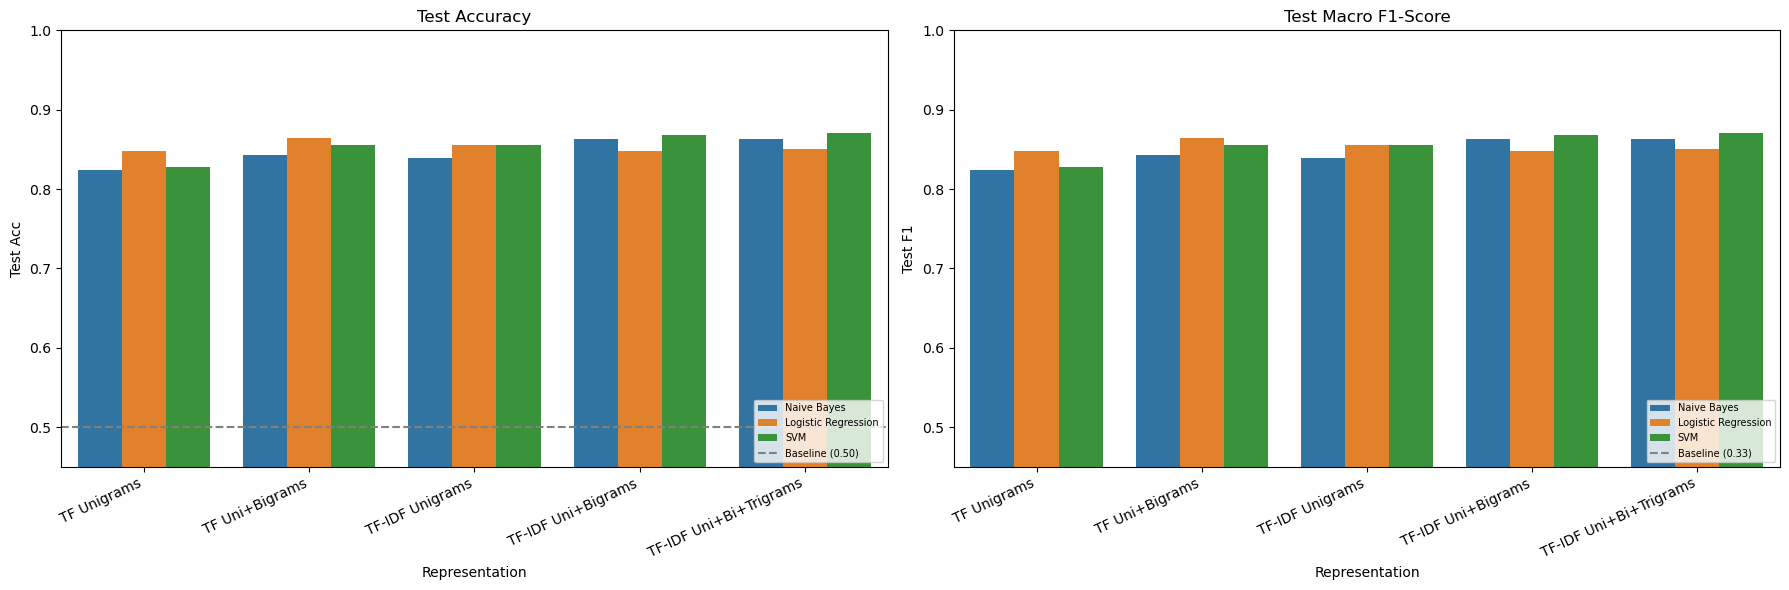

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=results_df, x='Representation', y='Test Acc', hue='Classifier', ax=axes[0])
axes[0].axhline(y=baseline_acc, color='gray', linestyle='--', label=f'Baseline ({baseline_acc:.2f})')
axes[0].set_title('Test Accuracy'); axes[0].set_ylim(0.45, 1.0)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha='right')
axes[0].legend(loc='lower right', fontsize=7)

sns.barplot(data=results_df, x='Representation', y='Test F1', hue='Classifier', ax=axes[1])
axes[1].axhline(y=baseline_f1, color='gray', linestyle='--', label=f'Baseline ({baseline_f1:.2f})')
axes[1].set_title('Test Macro F1-Score'); axes[1].set_ylim(0.45, 1.0)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')
axes[1].legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Best: TF-IDF Uni+Bi+Trigrams + SVM → Acc=0.8710 | F1=0.8710

              precision    recall  f1-score   support

    negative       0.86      0.88      0.87      1000
    positive       0.88      0.86      0.87      1000

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



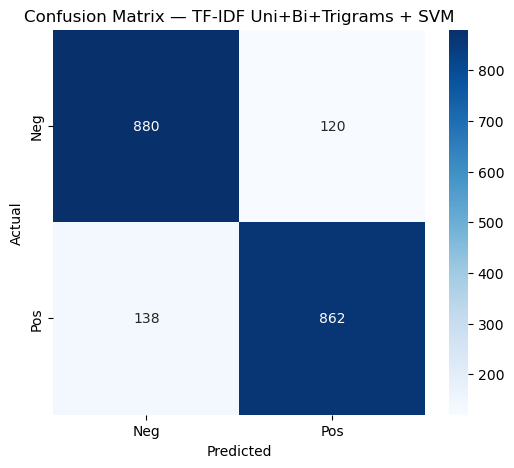

In [18]:
# Best model details
best_row = results_df.loc[results_df['Test F1'].idxmax()]
best_repr, best_clf_name = best_row['Representation'], best_row['Classifier']
print(f"Best: {best_repr} + {best_clf_name} → Acc={best_row['Test Acc']:.4f} | F1={best_row['Test F1']:.4f}")

X_tr, X_te = representations[best_repr]
clf = classifiers[best_clf_name]; clf.fit(X_tr, y_train)
y_pred = clf.predict(X_te)
print(f"\n{classification_report(y_test, y_pred)}")

cm = confusion_matrix(y_test, y_pred, labels=['negative','positive'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_repr} + {best_clf_name}')
plt.savefig('confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

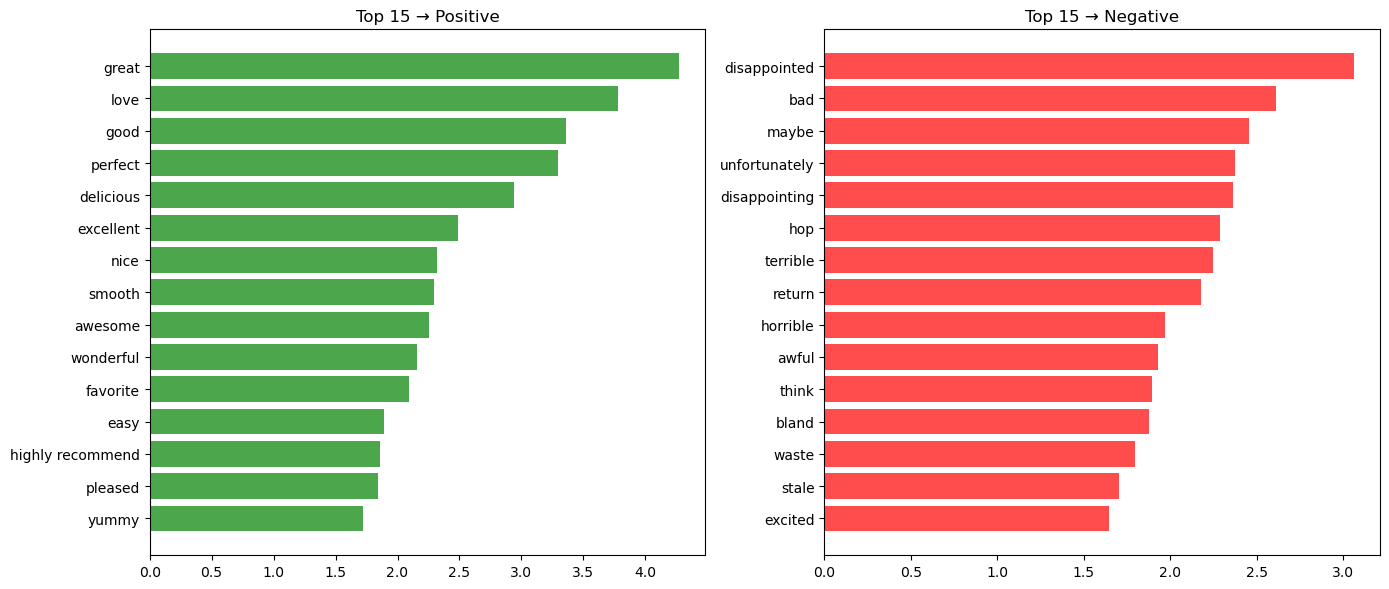

In [19]:
# Most discriminative features
vmap = {'TF Unigrams':tf_uni,'TF Uni+Bigrams':tf_bi,'TF-IDF Unigrams':tfidf_uni,'TF-IDF Uni+Bigrams':tfidf_bi,'TF-IDF Uni+Bi+Trigrams':tfidf_tri}
fnames = vmap[best_repr].get_feature_names_out()
coefs = clf.coef_[0] if hasattr(clf,'coef_') else clf.feature_log_prob_[1]-clf.feature_log_prob_[0]

fig, axes = plt.subplots(1,2,figsize=(14,6))
for ax, idx, color, title in [(axes[0], coefs.argsort()[-15:][::-1], 'green', 'Top 15 → Positive'),
                               (axes[1], coefs.argsort()[:15], 'red', 'Top 15 → Negative')]:
    vals = [abs(coefs[i]) for i in idx]
    ax.barh(range(15), vals, color=color, alpha=0.7)
    ax.set_yticks(range(15)); ax.set_yticklabels([fnames[i] for i in idx])
    ax.invert_yaxis(); ax.set_title(title)
plt.tight_layout()
plt.savefig('most_important_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sentence Embeddings (BERT-based)

In [20]:
from sentence_transformers import SentenceTransformer

print("Loading SentenceTransformer...")
st_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding train (8,000)...")
X_train_emb = st_model.encode(X_train_raw.tolist(), show_progress_bar=True, batch_size=128)
print("Encoding test (2,000)...")
X_test_emb = st_model.encode(X_test_raw.tolist(), show_progress_bar=True, batch_size=128)
print(f"Shape: {X_train_emb.shape}")

Loading SentenceTransformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding train (8,000)...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Encoding test (2,000)...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Shape: (8000, 384)


In [21]:
cv_emb = cross_validate(LogisticRegression(max_iter=1000, random_state=42),
                        X_train_emb, y_train, cv=cv, scoring=scoring)
clf_emb = LogisticRegression(max_iter=1000, random_state=42)
clf_emb.fit(X_train_emb, y_train)
y_pred_emb = clf_emb.predict(X_test_emb)
acc_emb = accuracy_score(y_test, y_pred_emb)
f1_emb = f1_score(y_test, y_pred_emb, average='macro')

print(f"Sent. Emb. (BERT) + LR: CV F1={cv_emb['test_f1_macro'].mean():.3f}±{cv_emb['test_f1_macro'].std():.3f} | Test F1={f1_emb:.4f}")
print(f"\n{classification_report(y_test, y_pred_emb)}")

results_df = pd.concat([results_df, pd.DataFrame([{
    'Representation':'Sent. Emb. (BERT)', 'Classifier':'Logistic Regression',
    'CV Acc':f"{cv_emb['test_accuracy'].mean():.3f}±{cv_emb['test_accuracy'].std():.3f}",
    'CV F1':f"{cv_emb['test_f1_macro'].mean():.3f}±{cv_emb['test_f1_macro'].std():.3f}",
    'Test Acc':acc_emb, 'Test F1':f1_emb,
}])], ignore_index=True)

Sent. Emb. (BERT) + LR: CV F1=0.801±0.014 | Test F1=0.7980

              precision    recall  f1-score   support

    negative       0.80      0.80      0.80      1000
    positive       0.80      0.80      0.80      1000

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



## 8. Final Comparison

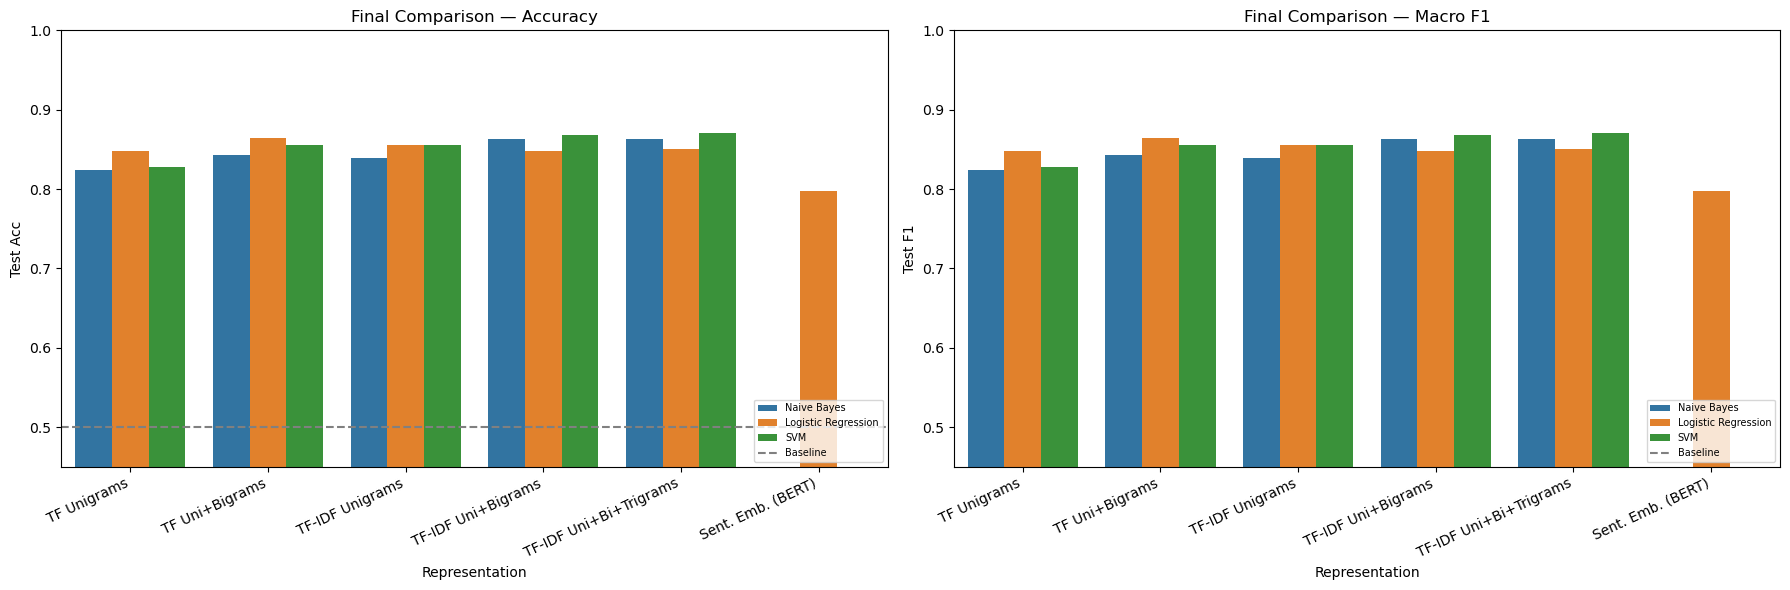

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, metric, title in [(axes[0],'Test Acc','Accuracy'), (axes[1],'Test F1','Macro F1')]:
    sns.barplot(data=results_df, x='Representation', y=metric, hue='Classifier', ax=ax)
    ax.axhline(y=baseline_acc if metric=='Test Acc' else baseline_f1, color='gray', linestyle='--', label='Baseline')
    ax.set_title(f'Final Comparison — {title}'); ax.set_ylim(0.45,1.0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print("=" * 105)
print("FINAL SUMMARY")
print("=" * 105)
print(results_df[['Representation','Classifier','CV F1','Test Acc','Test F1']].to_string(index=False))
best = results_df.loc[results_df['Test F1'].idxmax()]
print(f"\nBest: {best['Representation']} + {best['Classifier']} → F1={best['Test F1']:.4f}")
print(f"Baseline: Acc={baseline_acc:.3f} | F1={baseline_f1:.3f}")

FINAL SUMMARY
        Representation          Classifier       CV F1  Test Acc  Test F1
           TF Unigrams         Naive Bayes 0.829±0.010    0.8240 0.823975
           TF Unigrams Logistic Regression 0.846±0.012    0.8480 0.847985
           TF Unigrams                 SVM 0.819±0.013    0.8280 0.827986
        TF Uni+Bigrams         Naive Bayes 0.840±0.015    0.8435 0.843489
        TF Uni+Bigrams Logistic Regression 0.853±0.011    0.8640 0.863991
        TF Uni+Bigrams                 SVM 0.839±0.015    0.8560 0.855995
       TF-IDF Unigrams         Naive Bayes 0.841±0.009    0.8390 0.838990
       TF-IDF Unigrams Logistic Regression 0.853±0.009    0.8560 0.855942
       TF-IDF Unigrams                 SVM 0.846±0.010    0.8550 0.854975
    TF-IDF Uni+Bigrams         Naive Bayes 0.852±0.015    0.8635 0.863488
    TF-IDF Uni+Bigrams Logistic Regression 0.854±0.013    0.8480 0.847970
    TF-IDF Uni+Bigrams                 SVM 0.859±0.011    0.8675 0.867493
TF-IDF Uni+Bi+Trigrams  

## 9. Error Analysis

In [24]:
X_tr, X_te = representations[best_repr]
clf = classifiers[best_clf_name]; clf.fit(X_tr, y_train)
y_pred = clf.predict(X_te)

test_df = pd.DataFrame({'text_original': df.loc[X_test_raw.index,'text'].values, 'actual':y_test.values, 'predicted':y_pred})
mis = test_df[test_df['actual'] != test_df['predicted']]
print(f"Misclassified: {len(mis)} / {len(test_df)} ({len(mis)/len(test_df)*100:.1f}%)")

print("\n--- FALSE POSITIVES ---")
for _, r in mis[mis['predicted']=='positive'].head(3).iterrows():
    print(f"  {r['text_original'][:200]}...\n")
print("--- FALSE NEGATIVES ---")
for _, r in mis[mis['predicted']=='negative'].head(3).iterrows():
    print(f"  {r['text_original'][:200]}...\n")

Misclassified: 258 / 2000 (12.9%)

--- FALSE POSITIVES ---
  I think that its wonderful that this is 100% dairy free, but I would rather just stick with dark chocolate then this bar.  It is rather smooth which is nice, but it has such a fake flavor of chocolate...

  I love Facebook.  I am just one person but I sent a message out about the insulting message I received from this company in response to my email request to sever ties with Rush Limbaugh.  I reached ov...

  This tea sounded great. I lived in the middle east and love the real moroccan mint tea. The real tea includes spearmint and green tea only. Honey is typically added. In this case all you can taste is ...

--- FALSE NEGATIVES ---
  I exercise in a competitive level. I ordered these biscuits after purchasing some chocolate chips in a specialize market. The natural ingredient list is what caught my attention. There are to many foo...

  the most economical way to buy the frontier lemon pepper (no salt).  i can't cook witho

In [25]:
print("Noun phrases in FALSE POSITIVES:")
for _, r in mis[mis['predicted']=='positive'].head(3).iterrows():
    doc = nlp(str(r['text_original'])[:500])
    print(f"  → {[c.text for c in doc.noun_chunks][:8]}")

print("\nNoun phrases in FALSE NEGATIVES:")
for _, r in mis[mis['predicted']=='negative'].head(3).iterrows():
    doc = nlp(str(r['text_original'])[:500])
    print(f"  → {[c.text for c in doc.noun_chunks][:8]}")

Noun phrases in FALSE POSITIVES:
  → ['I', 'this', 'I', 'dark chocolate', 'It', 'which', 'it', 'such a fake flavor']
  → ['I', 'Facebook', 'I', 'just one person', 'I', 'a message', 'the insulting message', 'I']
  → ['This tea', 'I', 'the middle east', 'the real moroccan mint tea', 'The real tea', 'spearmint', 'green tea', 'Honey']

Noun phrases in FALSE NEGATIVES:
  → ['I', 'a competitive level', 'I', 'these biscuits', 'some chocolate chips', 'a specialize market', 'The natural ingredient list', 'what']
  → ['the most economical way', 'the frontier lemon pepper', 'no salt', 'i', 'it']
  → ['I', 'the taste', 'just a touch', 'salt', 'they', 'more chewy', 'I', "The Gustaf's rounds"]


## 10. Preprocessing Ablation Study

Running ablation study on 4,000 reviews...

  Lowercase only       → CV F1=0.853±0.012 | Test F1=0.851
  Stopwords removed    → CV F1=0.835±0.009 | Test F1=0.813
  Stemmed              → CV F1=0.839±0.009 | Test F1=0.813
  Lemmatised           → CV F1=0.838±0.006 | Test F1=0.809


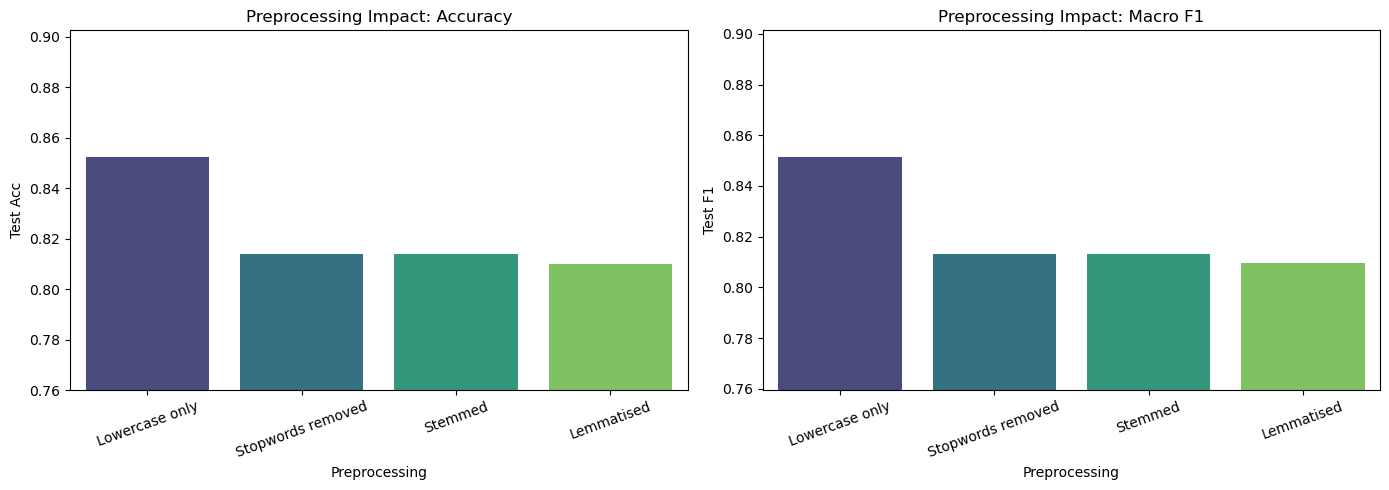

In [26]:
print("Running ablation study on 4,000 reviews...\n")
df_ab = df.sample(n=4000, random_state=42).copy()

df_ab['text_raw'] = df_ab['text'].astype(str).str.lower()
df_ab['text_no_stop'] = df_ab['text'].apply(lambda x: preprocess_text(x))
df_ab['text_stemmed'] = df_ab['text'].apply(lambda x: preprocess_text(x, use_stem=True))
df_ab['text_lemma'] = df_ab['text'].apply(lambda x: preprocess_text(x, use_lemma=True))

prep_variants = {'Lowercase only':'text_raw', 'Stopwords removed':'text_no_stop',
                 'Stemmed':'text_stemmed', 'Lemmatised':'text_lemma'}

ab_results = []
for name, col in prep_variants.items():
    Xtr,Xte,ytr,yte = train_test_split(df_ab[col], df_ab['sentiment'], test_size=0.2, random_state=42, stratify=df_ab['sentiment'])
    vec = TfidfVectorizer(ngram_range=(1,2), max_features=50000)
    Xtr_v, Xte_v = vec.fit_transform(Xtr), vec.transform(Xte)
    lr = LogisticRegression(max_iter=1000, random_state=42)
    cv_res = cross_validate(lr, Xtr_v, ytr, cv=cv, scoring=scoring)
    lr.fit(Xtr_v, ytr)
    tf1 = f1_score(yte, lr.predict(Xte_v), average='macro')
    ta = accuracy_score(yte, lr.predict(Xte_v))
    ab_results.append({'Preprocessing':name, 'CV F1':cv_res['test_f1_macro'].mean(),
                       'CV F1 std':cv_res['test_f1_macro'].std(), 'Test Acc':ta, 'Test F1':tf1})
    print(f"  {name:20s} → CV F1={cv_res['test_f1_macro'].mean():.3f}±{cv_res['test_f1_macro'].std():.3f} | Test F1={tf1:.3f}")

ab_df = pd.DataFrame(ab_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in [(axes[0],'Test Acc','Accuracy'), (axes[1],'Test F1','Macro F1')]:
    sns.barplot(data=ab_df, x='Preprocessing', y=metric, palette='viridis', ax=ax)
    ax.set_title(f'Preprocessing Impact: {title}')
    ax.set_ylim(max(0,ab_df[metric].min()-0.05), min(1,ab_df[metric].max()+0.05))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
plt.tight_layout()
plt.savefig('ablation_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print("\n✅ Project complete!")
print("Generated figures: review_length_distribution.png, wordclouds_sentiment.png,")
print("pos_analysis.png, ner_analysis.png, ngram_analysis.png, results_comparison.png,")
print("confusion_matrix_best.png, most_important_features.png, final_comparison.png, ablation_preprocessing.png")


✅ Project complete!
Generated figures: review_length_distribution.png, wordclouds_sentiment.png,
pos_analysis.png, ner_analysis.png, ngram_analysis.png, results_comparison.png,
confusion_matrix_best.png, most_important_features.png, final_comparison.png, ablation_preprocessing.png
